In [58]:
import numpy as np
import torch
import torch.nn as nn

torch.manual_seed(2003)
np.random.seed(2003)

In [59]:
class Saw(nn.Module):
    def forward(self, x):
        return torch.abs(torch.remainder(x, 1.0) - 0.5) - 0.25


class MountainGen(nn.Module):
    def __init__(self, octaves=4, hidden=32, latent=4):
        super().__init__()
        self.encoders = nn.ModuleList(
            [nn.Linear(2, latent) for _ in range(octaves)],
        )
        self.noise = nn.Sequential(
            nn.Linear(latent, hidden),
            Saw(),
            nn.Linear(hidden, 1),
        )
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.5)
            nn.init.normal_(m.bias, 0.0, 0.5)

    def forward(self, coords):
        zs = [self.noise(enc(coords)) for enc in self.encoders]
        z = torch.stack(zs, dim=0).mean(dim=0)
        return (1 - torch.abs(z)) / (1 + torch.norm(coords, dim=-1, keepdim=True) ** 2)


base_model = MountainGen()  # f(x, y) = z
print(sum(p.numel() for p in base_model.parameters()), "parameters")
base_model.eval()

241 parameters


MountainGen(
  (encoders): ModuleList(
    (0-3): 4 x Linear(in_features=2, out_features=4, bias=True)
  )
  (noise): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Saw()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [60]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def evaluate_on_grid(
    model, offset=(0, 0), x_range=(-1, 1), y_range=(-1, 1), resolution=128
):
    x = offset[0] + np.linspace(x_range[0], x_range[1], resolution)
    y = offset[1] + np.linspace(y_range[0], y_range[1], resolution)
    xx, yy = np.meshgrid(x, y)
    grid = np.stack([xx.flatten(), yy.flatten()], axis=-1)

    with torch.no_grad():
        inputs = torch.from_numpy(grid).float()
        raw = model(inputs).detach().cpu().numpy()
        if raw.ndim == 2 and raw.shape[1] == 1:
            raw = raw[:, 0]
        elif raw.ndim != 1:
            raise ValueError(
                f"Model must return one value per grid point, got shape {raw.shape}"
            )
        outputs = raw.reshape(resolution, resolution)

    return x, y, xx, yy, outputs


def plot_landscape(x, y, xx, yy, outputs):
    fig = make_subplots(
        rows=2,
        cols=1,
        specs=[[{"type": "surface"}], [{"type": "heatmap"}]],
        subplot_titles=("Surface", "Heightmap"),
        vertical_spacing=0.08,
    )

    fig.add_trace(
        go.Surface(z=outputs, x=xx, y=yy, colorscale="Earth", showscale=False),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Heatmap(
            z=outputs, x=x, y=y, colorscale="Earth", colorbar=dict(title="height")
        ),
        row=2,
        col=1,
    )

    fig.update_xaxes(title_text="x", row=1, col=1)
    fig.update_yaxes(title_text="y", row=1, col=1)
    fig.update_scenes(xaxis_title="x", yaxis_title="y", zaxis_title="height")
    fig.update_layout(height=1200, width=680, title="Landscape")
    fig.show()


offset = (0, 0)
r = 1
x, y, xx, yy, height = evaluate_on_grid(
    base_model, offset, x_range=(-r, r), y_range=(-r, r)
)
plot_landscape(x, y, xx, yy, height)

In [61]:
import numba as nb


@nb.njit
def sample_height_and_gradient(heightmap, x_pos, y_pos):
    x0 = int(x_pos)
    y0 = int(y_pos)
    x1 = x0 + 1
    y1 = y0 + 1

    sx = x_pos - x0
    sy = y_pos - y0

    h00 = heightmap[y0, x0]
    h10 = heightmap[y0, x1]
    h01 = heightmap[y1, x0]
    h11 = heightmap[y1, x1]

    h0 = h00 * (1.0 - sx) + h10 * sx
    h1 = h01 * (1.0 - sx) + h11 * sx
    h = h0 * (1.0 - sy) + h1 * sy

    grad_x = (h10 - h00) * (1.0 - sy) + (h11 - h01) * sy
    grad_y = (h01 - h00) * (1.0 - sx) + (h11 - h10) * sx
    return h, grad_x, grad_y


@nb.njit
def deposit_bilinear(heightmap, x_pos, y_pos, amount):
    x0 = int(x_pos)
    y0 = int(y_pos)
    x1 = x0 + 1
    y1 = y0 + 1

    sx = x_pos - x0
    sy = y_pos - y0

    w00 = (1.0 - sx) * (1.0 - sy)
    w10 = sx * (1.0 - sy)
    w01 = (1.0 - sx) * sy
    w11 = sx * sy

    heightmap[y0, x0] += amount * w00
    heightmap[y0, x1] += amount * w10
    heightmap[y1, x0] += amount * w01
    heightmap[y1, x1] += amount * w11


@nb.njit
def erode_with_brush(heightmap, x_pos, y_pos, amount, radius):
    center_x = int(x_pos)
    center_y = int(y_pos)
    h = heightmap.shape[0]
    w = heightmap.shape[1]

    total_weight = 0.0
    for oy in range(-radius, radius + 1):
        for ox in range(-radius, radius + 1):
            xi = center_x + ox
            yi = center_y + oy
            if xi <= 0 or xi >= w - 1 or yi <= 0 or yi >= h - 1:
                continue
            dist = (ox * ox + oy * oy) ** 0.5
            if dist > radius:
                continue
            total_weight += radius + 1.0 - dist

    if total_weight <= 0.0:
        return 0.0

    removed = 0.0
    for oy in range(-radius, radius + 1):
        for ox in range(-radius, radius + 1):
            xi = center_x + ox
            yi = center_y + oy
            if xi <= 0 or xi >= w - 1 or yi <= 0 or yi >= h - 1:
                continue
            dist = (ox * ox + oy * oy) ** 0.5
            if dist > radius:
                continue

            weight = radius + 1.0 - dist
            share = amount * (weight / total_weight)

            local_floor = 1e18
            for ny in range(yi - 1, yi + 2):
                for nx in range(xi - 1, xi + 2):
                    if ny == yi and nx == xi:
                        continue
                    v = heightmap[ny, nx]
                    if v < local_floor:
                        local_floor = v

            max_remove = heightmap[yi, xi] - local_floor
            if max_remove < 0.0:
                max_remove = 0.0

            delta = share
            if delta > max_remove:
                delta = max_remove

            heightmap[yi, xi] -= delta
            removed += delta

    return removed


@nb.njit
def diffuse_step(heightmap, alpha):
    src = heightmap.copy()
    h = heightmap.shape[0]
    w = heightmap.shape[1]

    for yi in range(1, h - 1):
        for xi in range(1, w - 1):
            lap = (
                src[yi - 1, xi]
                + src[yi + 1, xi]
                + src[yi, xi - 1]
                + src[yi, xi + 1]
                - 4.0 * src[yi, xi]
            )
            heightmap[yi, xi] = src[yi, xi] + alpha * lap


@nb.njit
def hydraulic_erosion_numba(
    heightmap,
    start_x,
    start_y,
    max_steps,
    inertia,
    capacity,
    min_slope,
    deposition,
    erosion,
    evaporation,
    gravity,
    max_deposit_step,
    max_erode_step,
    brush_radius,
    diffuse_every,
    diffuse_alpha,
):
    hm = heightmap.copy()
    h = hm.shape[0]
    w = hm.shape[1]
    iterations = start_x.shape[0]

    for drop_idx in range(iterations):
        x_pos = start_x[drop_idx]
        y_pos = start_y[drop_idx]

        dir_x = 0.0
        dir_y = 0.0
        speed = 1.0
        water = 1.0
        sediment = 0.0

        for _ in range(max_steps):
            if x_pos < 1.0 or x_pos >= w - 2.0 or y_pos < 1.0 or y_pos >= h - 2.0:
                break

            h_now, grad_x, grad_y = sample_height_and_gradient(hm, x_pos, y_pos)

            dir_x = dir_x * inertia - grad_x * (1.0 - inertia)
            dir_y = dir_y * inertia - grad_y * (1.0 - inertia)

            norm = (dir_x * dir_x + dir_y * dir_y) ** 0.5
            if norm < 1e-12:
                break

            dir_x /= norm
            dir_y /= norm

            new_x = x_pos + dir_x
            new_y = y_pos + dir_y
            if new_x < 1.0 or new_x >= w - 2.0 or new_y < 1.0 or new_y >= h - 2.0:
                break

            h_new, _, _ = sample_height_and_gradient(hm, new_x, new_y)
            delta_h = h_new - h_now

            slope = -delta_h
            if slope < min_slope:
                slope = min_slope
            sediment_capacity = slope * speed * water * capacity

            if delta_h > 0.0 or sediment > sediment_capacity:
                target = (
                    delta_h
                    if delta_h > 0.0
                    else (sediment - sediment_capacity) * deposition
                )
                deposit_amount = sediment
                if target < deposit_amount:
                    deposit_amount = target
                if max_deposit_step < deposit_amount:
                    deposit_amount = max_deposit_step

                if deposit_amount > 0.0:
                    deposit_bilinear(hm, x_pos, y_pos, deposit_amount)
                    sediment -= deposit_amount
            else:
                erode_amount = (sediment_capacity - sediment) * erosion
                downhill_limit = -delta_h
                if downhill_limit < erode_amount:
                    erode_amount = downhill_limit
                if max_erode_step < erode_amount:
                    erode_amount = max_erode_step

                if erode_amount > 0.0:
                    lifted = erode_with_brush(
                        hm, x_pos, y_pos, erode_amount, brush_radius
                    )
                    sediment += lifted

            speed_sq = speed * speed + (-delta_h) * gravity
            if speed_sq < 0.05:
                speed_sq = 0.05
            speed = speed_sq**0.5
            if speed > 3.0:
                speed = 3.0

            water *= 1.0 - evaporation
            x_pos = new_x
            y_pos = new_y

            if water < 0.02:
                break

        if diffuse_every > 0 and ((drop_idx + 1) % diffuse_every == 0):
            diffuse_step(hm, diffuse_alpha)

    return hm


def hydraulic_erosion(
    heightmap,
    iterations=25000,
    max_steps=45,
    inertia=0.15,
    capacity=1.6,
    min_slope=0.01,
    deposition=0.08,
    erosion=0.05,
    evaporation=0.03,
    gravity=4.0,
    max_deposit_step=0.025,
    max_erode_step=0.012,
    brush_radius=1,
    diffuse_every=6000,
    diffuse_alpha=0.01,
    seed=None,
):
    rng = np.random.default_rng(seed)
    h, w = heightmap.shape
    start_x = rng.uniform(1.0, w - 2.0, size=iterations).astype(np.float64)
    start_y = rng.uniform(1.0, h - 2.0, size=iterations).astype(np.float64)

    hm64 = np.asarray(heightmap, dtype=np.float64)
    eroded = hydraulic_erosion_numba(
        hm64,
        start_x,
        start_y,
        max_steps,
        inertia,
        capacity,
        min_slope,
        deposition,
        erosion,
        evaporation,
        gravity,
        max_deposit_step,
        max_erode_step,
        int(brush_radius),
        int(diffuse_every),
        diffuse_alpha,
    )
    return eroded.astype(heightmap.dtype, copy=False)


eroded_height = hydraulic_erosion(height)
plot_landscape(x, y, xx, yy, eroded_height)


def plot_diff_heatmap(diff):
    fig = go.Figure(data=go.Heatmap(z=diff, colorscale="RdBu"))
    fig.update_layout(height=680, width=680, title="Height Difference")
    fig.show()


height_diff = eroded_height - height
plot_diff_heatmap(height_diff)

In [ ]:
# TODO: properly inspect its learning, the gradients and the final weigths distro
class MountainApprox(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        # TODO: also think onto how to compress parameters - mb convs instead of linear layers? then what type of convs - e.g. maybe need to make it multichannel of features
        # TODO: also a peeling idea is that somehere inside the model there must exist parameters that can be changed providing entropy for it to genrate mountains
        self.input_wrap = nn.Sequential(
            nn.Linear(2, hidden_dim),
            Saw(),
            nn.Linear(hidden_dim, 2),
        )
        self.apply(self._init_weights)

    def _init_weights(self, m):
        # TODO: search a better init
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, 0.0, 0.5)
            nn.init.normal_(m.bias, 0.0, 0.5)

    def forward(self, coords):
        # TODO: search better input / ouput warp

        # TODO: investigate forms of stacking refinements
        # - the questions are
        # 1) where to stack refinements: into the noise or to the z level
        # 2) how to stack refinements: like in boosting doing it greedily or simply add and see the gradinent going its job
        # 3) what a model sizes will be optimal for each next refinement

        # warp coords
        coords = coords + 0.5 * self.input_wrap(coords)

        # just a parabolic elevation
        z = torch.sqrt(coords[:, 0] ** 2 + coords[:, 1] ** 2).unsqueeze(1)  # (N,1)
        return 1.0 - z  # (N,1)


# eroded_model = MountainGen()
eroded_model = (
    MountainApprox()
)  # seems that this is better at approximating a eroded surface
print(sum(p.numel() for p in eroded_model.parameters()), "parameters")

642 parameters


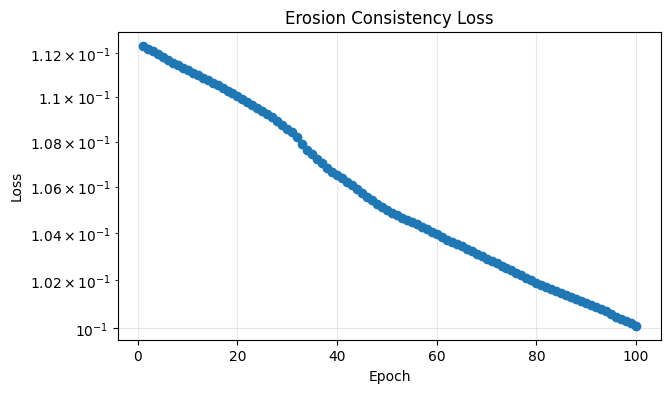

epoch 300/300 | loss = 0.100106


MountainApprox(
  (input_wrap): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Saw()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

In [71]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import torch


epochs = 300
steps_per_epoch = 5
learning_rate = 1e-3
seed = 2026
max_epoch_losses = 100

value_loss_weight = 0.5
grad_loss_weight = 0.5

resolution = 128

dx = 2 / (resolution - 1)
dy = 2 / (resolution - 1)


torch.manual_seed(seed)
np.random.seed(seed)


def spatial_grads(h):
    gx = (h[:, 1:] - h[:, :-1]) / dx
    gy = (h[1:, :] - h[:-1, :]) / dy
    return gx, gy


x = offset[0] + np.linspace(-1, 1, resolution)
y = offset[1] + np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(x, y)

local_coords_t = torch.as_tensor(
    np.stack([xx.reshape(-1), yy.reshape(-1)], axis=-1),
    dtype=torch.float32,
)

eroded_model.train()
optimizer = torch.optim.Adam(eroded_model.parameters(), lr=learning_rate)


# ----- precompute erosion target -----

with torch.no_grad():
    base_height = base_model(local_coords_t).reshape(resolution, resolution)

    base_np = base_height.detach().cpu().numpy().astype(np.float32)
    eroded_np = hydraulic_erosion(base_np, seed=seed).astype(np.float32)

    target = torch.from_numpy(eroded_np).to(
        dtype=base_height.dtype,
    )

    target_gx, target_gy = spatial_grads(target)

# ----- / precompute erosion target -----


epoch_losses = []
fig, ax = plt.subplots(figsize=(7, 4))

for epoch in range(1, epochs + 1):
    step_losses = []

    for _ in range(steps_per_epoch):
        pred = eroded_model(local_coords_t).reshape(resolution, resolution)

        value_loss = ((target - pred) ** 2).mean()

        pred_gx, pred_gy = spatial_grads(pred)
        grad_loss = ((target_gx - pred_gx) ** 2).mean() + (
            (target_gy - pred_gy) ** 2
        ).mean()

        loss = value_loss_weight * value_loss + grad_loss_weight * grad_loss

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        step_losses.append(loss.detach().cpu().item())

    epoch_loss = float(np.mean(step_losses))

    epoch_losses.append(epoch_loss)
    if len(epoch_losses) > max_epoch_losses:
        epoch_losses.pop(0)

    clear_output(wait=True)

    ax.clear()
    ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker="o", linewidth=1.5)
    ax.set_yscale("log")
    ax.set_title("Erosion Consistency Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

    display(fig)

    print(f"epoch {epoch:02d}/{epochs} | loss = {epoch_loss:.6f}")


plt.close(fig)
eroded_model.eval()

In [ ]:
offset = (0, 0)
r = 1
x, y, xx, yy, approx_eroded_height = evaluate_on_grid(
    eroded_model, offset, x_range=(-r, r), y_range=(-r, r)
)
plot_landscape(x, y, xx, yy, approx_eroded_height)

plot_diff_heatmap(target - approx_eroded_height)

C:\Users\shich\AppData\Local\Temp\ipykernel_24860\3065713227.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plot_diff_heatmap(target - approx_eroded_height)
